In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import re

plt.rcParams['font.family'] = 'arial'


In [ ]:
'''
import ast

for data_split in ['train', 'test', 'pred']:
    df = pd.read_csv(f'{data_split}.csv')
    df['embedding'] = df['embedding'].apply(ast.literal_eval)
    embeddings = np.vstack(df['embedding'].values)
    print(f"For split {data_split}, we have {embeddings.shape[0]} points")
    np.savetxt(f'embeddings_{data_split}.csv', embeddings)
'''


In [2]:
formula_train = pd.read_csv(f'train.csv')[['Formula']]
formula_test = pd.read_csv(f'test.csv')[['Formula']]
formula_pred = pd.read_csv(f'pred.csv')[['Formula']]

formula_all = pd.concat([formula_train, formula_test, formula_pred])

optimized_comp = ['Ge0.500Ag0.100Sb0.300Bi0.100Te', 'Ge0.500Ag0.300Sb0.100Bi0.100Te', 'Ge0.500Ag0.100Al0.100Sb0.300Te', 'Ge0.500Sb0.300Bi0.100Y0.100Te', 'Ge0.500Al0.100Sb0.300Bi0.100Te']
formula_pred['top'] = formula_pred['Formula'].isin(optimized_comp)
formula_pred[formula_pred['top']==True]

,Formula,top
4,Ge0.500Ag0.100Al0.100Sb0.300Te,True
162,Ge0.500Ag0.100Sb0.300Bi0.100Te,True
410,Ge0.500Ag0.300Sb0.100Bi0.100Te,True
514,Ge0.500Al0.100Sb0.300Bi0.100Te,True
9959,Ge0.500Sb0.300Bi0.100Y0.100Te,True


In [3]:
def update_elements(df):

    elements = [
        'H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F', 'Ne',
        'Na', 'Mg', 'Al', 'Si', 'P', 'S', 'Cl', 'Ar', 'K', 'Ca',
        'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn',
        'Ga', 'Ge', 'As', 'Se', 'Br', 'Kr', 'Rb', 'Sr', 'Y', 'Zr',
        'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd', 'In', 'Sn',
        'Sb', 'Te', 'I', 'Xe', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd',
        'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb',
        'Lu', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg',
        'Tl', 'Pb', 'Bi', 'Po', 'At', 'Rn', 'Fr', 'Ra', 'Ac', 'Th',
        'Pa', 'U', 'Np', 'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm',
        'Md', 'No', 'Lr', 'Rf', 'Db', 'Sg', 'Bh', 'Hs', 'Mt', 'Ds',
        'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv', 'Ts', 'Og'
    ]
    
    # Sort elements by length (descending) to match longer elements first
    # This prevents 'S' from matching in 'Sm' for example
    elements_sorted = sorted(elements, key=len, reverse=True)
    
    for element in elements_sorted:
        # More sophisticated pattern that handles various chemical notation
        pattern = r'(?<![a-z])' + re.escape(element) + r'(?=\d|[A-Z]|[\[\(\)\]\·\s]|$)'
        
        df[element] = df['Formula'].str.contains(
            pattern, 
            case=True, 
            na=False, 
            regex=True
        )

    return df

formula_train = update_elements(formula_train)
formula_test = update_elements(formula_test)

C:\Users\lowka\AppData\Local\Temp\ipykernel_31028\2902556171.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[element] = df['Formula'].str.contains(
C:\Users\lowka\AppData\Local\Temp\ipykernel_31028\2902556171.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[element] = df['Formula'].str.contains(
C:\Users\lowka\AppData\Local\Temp\ipykernel_31028\2902556171.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Conside

In [5]:
def count_elements(df):

    elements = [
        'H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F', 'Ne',
        'Na', 'Mg', 'Al', 'Si', 'P', 'S', 'Cl', 'Ar', 'K', 'Ca',
        'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn',
        'Ga', 'Ge', 'As', 'Se', 'Br', 'Kr', 'Rb', 'Sr', 'Y', 'Zr',
        'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd', 'In', 'Sn',
        'Sb', 'Te', 'I', 'Xe', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd',
        'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb',
        'Lu', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg',
        'Tl', 'Pb', 'Bi', 'Po', 'At', 'Rn', 'Fr', 'Ra', 'Ac', 'Th',
        'Pa', 'U', 'Np', 'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm',
        'Md', 'No', 'Lr', 'Rf', 'Db', 'Sg', 'Bh', 'Hs', 'Mt', 'Ds',
        'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv', 'Ts', 'Og'
    ]
    
    element_counts = []
    i = 1
    for element in elements:
        if element in df.columns:
            count = df[element].sum()
            element_counts.append({
                'Element_Symbol': element,
                'Atomic Num': i,
                'Count': count
            })

        i+=1
    
    # Create the count dataframe
    count_df = pd.DataFrame(element_counts)

    return count_df

count_train = count_elements(formula_train)
count_test = count_elements(formula_test)

<BarContainer object of 118 artists>

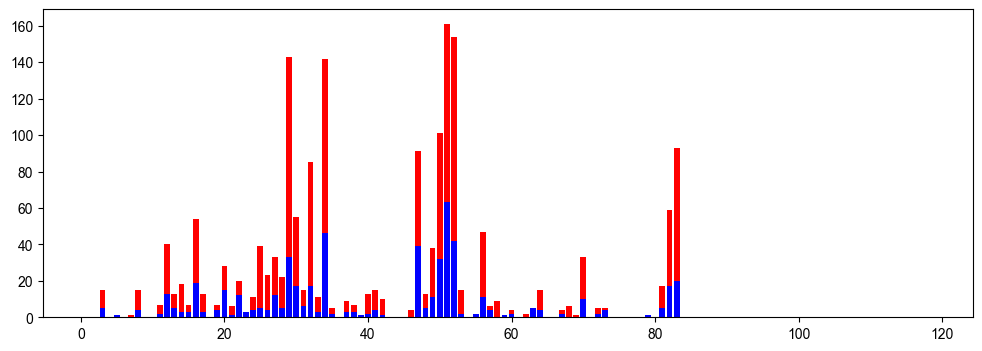

In [6]:
fig, ax = plt.subplots(figsize=(12,4))

ax.bar(count_train['Atomic Num'], count_train['Count'], color='r')
ax.bar(count_test['Atomic Num'], count_test['Count'], color='b')

In [7]:
count_traintest = count_train[['Element_Symbol']].copy()
count_traintest['Count'] = count_train['Count'] + count_test['Count']

count_traintest = count_traintest[count_traintest['Count']>0]

count_traintest

,Element_Symbol,Count
2,Li,20
4,B,1
6,N,1
7,O,19
10,Na,9
...,...,...
72,Ta,9
78,Au,1
80,Tl,22
81,Pb,76


In [8]:
count_traintest.to_csv('traintest_counts.csv', header=None, index=None)

In [9]:
from bokeh.io import output_notebook
output_notebook()

from periodic_trends import plotter
plotter(
    'traintest_counts.csv', 
    cmap="viridis", alpha=0.7, extended=False,
    
)

Loading BokehJS ...

figure(id='p1005', ...)

In [11]:
embeddings_train = np.loadtxt(f'embeddings_train.csv')
embeddings_test = np.loadtxt(f'embeddings_test.csv')
embeddings_pred = np.loadtxt(f'embeddings_pred.csv')

embeddings_all = np.vstack([embeddings_train, embeddings_test, embeddings_pred])

In [12]:
embeddings_train.shape, embeddings_test.shape, embeddings_pred.shape, embeddings_all.shape

((571, 512), (169, 512), (26131, 512), (26871, 512))

In [29]:
formula_train.iloc[0]['Formula']

'(Ag0.05Sb0.05Sn0.9)(S0.05Se0.05Te0.9)'

In [113]:
df_train = pd.read_csv("train_predictions_run_1.csv")
df_val = pd.read_csv("val_predictions_run_1.csv")

df_val = df_val.drop(62)

In [121]:
train_agg_zt = pd.DataFrame(columns=['composition', 'agg_zt'])

for formula in formula_train['Formula']:
    df_temp = df_train[df_train['composition']==formula].sort_values(by='temperature(K)')
    if len(df_temp) < 2:
        agg_zt = np.nan
    else:
        agg_zt = np.trapezoid(df_temp['true_ZT'], df_temp['temperature(K)']) / (df_temp['temperature(K)'].max() - df_temp['temperature(K)'].min())

    train_agg_zt.loc[len(train_agg_zt)] = [formula, agg_zt]

val_agg_zt = pd.DataFrame(columns=['composition', 'agg_zt'])

for formula in formula_test['Formula']:
    df_temp = df_val[df_val['composition']==formula].sort_values(by='temperature(K)')
    if len(df_temp) < 2:
        agg_zt = np.nan
    else:
        agg_zt = np.trapezoid(df_temp['true_ZT'], df_temp['temperature(K)']) / (df_temp['temperature(K)'].max() - df_temp['temperature(K)'].min())

    val_agg_zt.loc[len(val_agg_zt)] = [formula, agg_zt]

all_agg_zt = pd.concat([train_agg_zt, val_agg_zt])
train_agg_zt.shape, val_agg_zt.shape, all_agg_zt.shape

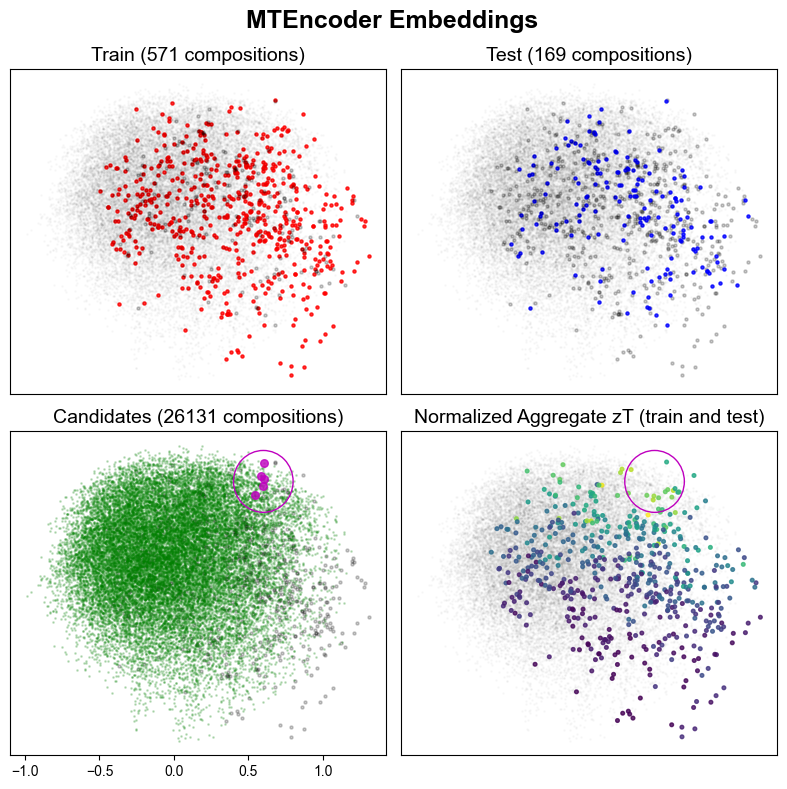

In [143]:
pca = PCA(n_components=2)
embeddings_all_pca = pca.fit_transform(embeddings_all)

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(8,8))

ax[0, 0].scatter(embeddings_all_pca[:embeddings_train.shape[0],0],
           embeddings_all_pca[:embeddings_train.shape[0],1],
           c='r', s=5, alpha=0.8)

ax[0, 0].scatter(embeddings_all_pca[embeddings_train.shape[0]:embeddings_train.shape[0]+embeddings_test.shape[0],0],
           embeddings_all_pca[embeddings_train.shape[0]:embeddings_train.shape[0]+embeddings_test.shape[0],1],
           c='k', s=5, alpha=0.2)

ax[0, 0].scatter(embeddings_all_pca[-embeddings_pred.shape[0]:,0],
           embeddings_all_pca[-embeddings_pred.shape[0]:,1],
           c='k', s=1, alpha=0.02)

ax[0, 1].scatter(embeddings_all_pca[:embeddings_train.shape[0],0],
           embeddings_all_pca[:embeddings_train.shape[0],1],
           c='k', s=5, alpha=0.2)

ax[0, 1].scatter(embeddings_all_pca[embeddings_train.shape[0]:embeddings_train.shape[0]+embeddings_test.shape[0],0],
           embeddings_all_pca[embeddings_train.shape[0]:embeddings_train.shape[0]+embeddings_test.shape[0],1],
           c='b', s=5, alpha=0.8)

ax[0, 1].scatter(embeddings_all_pca[-embeddings_pred.shape[0]:,0],
           embeddings_all_pca[-embeddings_pred.shape[0]:,1],
           c='k', s=1, alpha=0.02)

ax[1, 0].scatter(embeddings_all_pca[:embeddings_train.shape[0],0],
           embeddings_all_pca[:embeddings_train.shape[0],1],
           c='k', s=5, alpha=0.2)

ax[1, 0].scatter(embeddings_all_pca[embeddings_train.shape[0]:embeddings_train.shape[0]+embeddings_test.shape[0],0],
           embeddings_all_pca[embeddings_train.shape[0]:embeddings_train.shape[0]+embeddings_test.shape[0],1],
           c='k', s=5, alpha=0.2)

ax[1, 0].scatter(embeddings_all_pca[-embeddings_pred.shape[0]:,0],
           embeddings_all_pca[-embeddings_pred.shape[0]:,1],
           c='g', s=1, alpha=0.2)


ax[1, 0].scatter(embeddings_all_pca[-embeddings_pred.shape[0]:,0][formula_pred['top']==True],
           embeddings_all_pca[-embeddings_pred.shape[0]:,1][formula_pred['top']==True],
           c='m', s=30, alpha=0.8)

ax[1, 1].scatter(embeddings_all_pca[-embeddings_pred.shape[0]:,0],
           embeddings_all_pca[-embeddings_pred.shape[0]:,1],
           c='k', s=1, alpha=0.02)

ax[1, 1].scatter(
    embeddings_all_pca[:embeddings_train.shape[0]+embeddings_test.shape[0],0],
    embeddings_all_pca[:embeddings_train.shape[0]+embeddings_test.shape[0],1],
    c=all_agg_zt['agg_zt'], s=7, alpha=0.8)


circle = plt.Circle((0.6, 0.5), 0.2, color='m', fc='None')
ax[1, 0].add_patch(circle)
circle = plt.Circle((0.6, 0.5), 0.2, color='m', fc='None')
ax[1, 1].add_patch(circle)


ax[0, 0].xaxis.set_visible(False) 
ax[0, 0].yaxis.set_visible(False)  
ax[0, 1].xaxis.set_visible(False) 
ax[0, 1].yaxis.set_visible(False)  
ax[1, 0].yaxis.set_visible(False)  
ax[1, 0].yaxis.set_visible(False)  
ax[1, 1].xaxis.set_visible(False) 
ax[1, 1].yaxis.set_visible(False)  

ax[0, 0].set_title("Train (571 compositions)", fontsize=14)
ax[0, 1].set_title("Test (169 compositions)", fontsize=14)
ax[1, 0].set_title("Candidates (26131 compositions)", fontsize=14)
ax[1, 1].set_title("Normalized Aggregate zT (train and test)", fontsize=14)

fig.suptitle("MTEncoder Embeddings", fontsize=18, fontweight='bold')

plt.tight_layout()

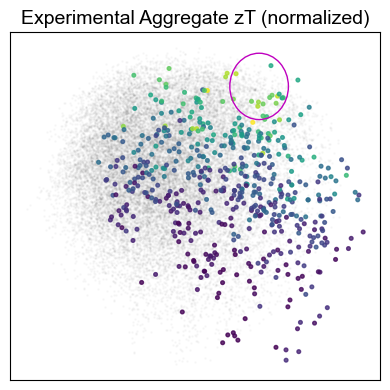

In [137]:
pca = PCA(n_components=2)
embeddings_all_pca = pca.fit_transform(embeddings_all)

fig, ax = plt.subplots(ncols=1, figsize=(4,4))


plt.tight_layout()

In [78]:
embeddings_all_pca[-embeddings_pred.shape[0]:,0][formula_pred['contains_Si']==True]

array([ 0.43521585,  0.16207539,  0.44077333, ...,  0.00810332,
       -0.35206276, -0.15890976], shape=(3005,))

In [47]:
formula_train = pd.read_csv(f'train.csv')[['Formula']]
formula_test = pd.read_csv(f'test.csv')[['Formula']]
formula_pred = pd.read_csv(f'pred.csv')[['Formula']]

formula_all = pd.concat([formula_train, formula_test, formula_pred])
formula_all['contains_Si'] = formula_all['Formula'].str.contains(r'(?<![a-zA-Z])Si(?![a-zA-Z])')


formula_all

,Formula,contains_Si
0,(Ag0.05Sb0.05Sn0.9)(S0.05Se0.05Te0.9),False
1,(Bi0.23Sb0.77)2Te3,False
2,(CaZn0.4Ag0.2Sb)0.83(LiZnSb)0.17,False
3,(CaZn0.4Ag0.2Sb)0.87(LiZnSb)0.13,False
4,(Cu0.001Pb0.999Te)(MnTe)0.03,False
...,...,...
26126,Ge0.925Bi0.025Cd0.025Te,False
26127,Ge0.95Bi0.025Te0.975(CdTe)0.025,False
26128,Ge0.95Bi0.05Te,False
26129,Ge0.975Bi0.025Te,False


,Formula,contains_Si,top10,top
4,Ge0.500Ag0.100Al0.100Sb0.300Te,False,False,True
162,Ge0.500Ag0.100Sb0.300Bi0.100Te,False,False,True
410,Ge0.500Ag0.300Sb0.100Bi0.100Te,False,False,True
514,Ge0.500Al0.100Sb0.300Bi0.100Te,False,True,True
9959,Ge0.500Sb0.300Bi0.100Y0.100Te,False,False,True


In [34]:
embeddings_all_pca[formula_all[formula_all['contains_Si']==True].index]

array([[ 0.35791347, -0.11252095],
       [ 0.60366049, -0.14890937],
       [ 0.48458633, -0.12022158],
       ...,
       [-0.28533026,  0.12698212],
       [-0.23968904, -0.0124532 ],
       [-0.51415666,  0.40493962]], shape=(3025, 2))

In [37]:
embeddings_all_pca[formula_all[formula_all['contains_Si']==True].index][:,0],

(array([ 0.35791347,  0.60366049,  0.48458633, ..., -0.28533026,
        -0.23968904, -0.51415666], shape=(3025,)),)